<a href="https://colab.research.google.com/github/ritikyadav9021/MDM-ML-LAB-/blob/main/Practical_10_EE554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self, output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, learning_rate):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient


In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))


def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)


In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(
            output_gradient,
            self.activation_prime(self.input)
        )

In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1 - np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)

In [ ]:
class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1 - s)

        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [ ]:
X = np.linspace(-3, 3, 61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):

    error = 0

    for x, y in zip(X, Y):

        output = np.array([[x]])

        for layer in network:
            output = layer.forward(output)

        error += mse(y, output)

        grad = mse_prime(y, output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)

    error /= len(X)

    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=15.030208768232077
2/50, error=1.4688208807295506
3/50, error=0.7346407799059382
4/50, error=0.04560888824492596
5/50, error=0.10057694612148961
6/50, error=0.04766597287459835
7/50, error=0.05524821184673114
8/50, error=0.02967785188343515
9/50, error=0.02460422671627686
10/50, error=0.013176700982679403
11/50, error=0.009765533517510958
12/50, error=0.006120276223866013
13/50, error=0.0054850084735853216
14/50, error=0.0052087653022369
15/50, error=0.0063952033455991104
16/50, error=0.008204998598423614
17/50, error=0.011194004933720324
18/50, error=0.014764172486407486
19/50, error=0.018970855146319916
20/50, error=0.023308421477261067
21/50, error=0.027793567842011497
22/50, error=0.03218501803704498
23/50, error=0.036441133367076425
24/50, error=0.04029575006796295
25/50, error=0.0435777792163294
26/50, error=0.046107494215444425
27/50, error=0.047852133440884785
28/50, error=0.048836692570335766
29/50, error=0.04914814529889834
30/50, error=0.04887897903965786
31/50, 

In [ ]:
actual_Y = []

for x in X:
    output = np.array([[x]])

    for layer in network:
        output = layer.forward(output)

    actual_Y.append(output[0, 0])

    print(output)

[[-0.97220696]]
[[-0.97574474]]
[[-0.97927507]]
[[-0.9827715]]
[[-0.98619945]]
[[-0.98951363]]
[[-0.99265474]]
[[-0.99554497]]
[[-0.99808221]]
[[-1.00013241]]
[[-1.00151963]]
[[-1.0020133]]
[[-1.00131185]]
[[-0.99902247]]
[[-0.9946365]]
[[-0.98750087]]
[[-0.97678754]]
[[-0.96146476]]
[[-0.94027853]]
[[-0.91175755]]
[[-0.87426206]]
[[-0.8261017]]
[[-0.76574622]]
[[-0.69213542]]
[[-0.60505476]]
[[-0.50548333]]
[[-0.39576818]]
[[-0.27948244]]
[[-0.16092167]]
[[-0.04435547]]
[[0.06671755]]
[[0.17006282]]
[[0.26482986]]
[[0.35133978]]
[[0.43067616]]
[[0.50422218]]
[[0.57324449]]
[[0.63858314]]
[[0.70048488]]
[[0.75859968]]
[[0.81212871]]
[[0.8600728]]
[[0.90150709]]
[[0.93580064]]
[[0.96268807]]
[[0.982108]]
[[0.99382975]]
[[0.99707903]]
[[0.99045036]]
[[0.9722095]]
[[0.94081257]]
[[0.89537624]]
[[0.83595394]]
[[0.76362116]]
[[0.68042377]]
[[0.58921407]]
[[0.49337031]]
[[0.39641446]]
[[0.30159899]]
[[0.2115703]]
[[0.12819071]]


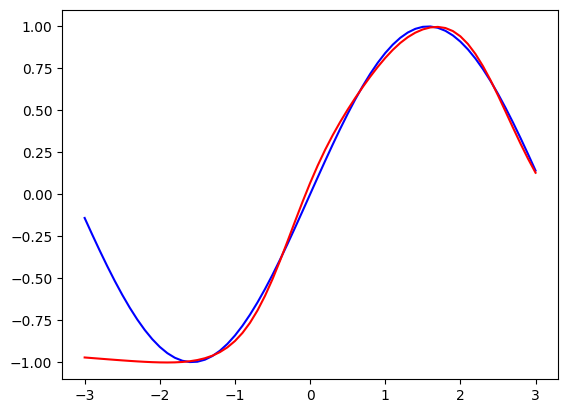

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X, Y, color='blue')
plt.plot(X, actual_Y, color='red')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
    x = x.reshape(x.shape[0], 28 * 28, 1)
    x = x.astype("float32") / 255

    y = to_categorical(y)
    y = y.reshape(y.shape[0], 10, 1)

    return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):

    error = 0

    for x, y in zip(x_train, y_train):

        output = x

        for layer in network:
            output = layer.forward(output)

        error += mse(y, output)

        grad = mse_prime(y, output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)

    error /= len(x_train)

    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=0.09777856152274182
2/50, error=0.0833463393225054
3/50, error=0.07556915958770996
4/50, error=0.06968361256837864
5/50, error=0.06540941812255258
6/50, error=0.062016612440231086
7/50, error=0.05799237984524871
8/50, error=0.05351423524999266
9/50, error=0.050658728048507094
10/50, error=0.04869583490697658
11/50, error=0.04721297718620734
12/50, error=0.046063636799659344
13/50, error=0.045145344478662044
14/50, error=0.04438373047105558
15/50, error=0.04373029933340817
16/50, error=0.043153359990046394
17/50, error=0.04263015142302262
18/50, error=0.04214245425895132
19/50, error=0.04166603387697766
20/50, error=0.04114763032922969
21/50, error=0.040418677930448316
22/50, error=0.03906653387491914
23/50, error=0.03768028457502993
24/50, error=0.036578941200241535
25/50, error=0.03579794493797461
26/50, error=0.03517085757934335
27/50, error=0.03463570992993649
28/50, error=0.034170465970101004
29/50, error=0.03375890508326455
30/50, error=0.033387366435826606
31/50, erro

In [ ]:
def predict(network, input):
    output = input

    for layer in network:
        output = layer.forward(output)

    return output

In [ ]:
!pip install simple-colors

import simple_colors

correct = 0

for x, y in zip(x_test, y_test):

    output = predict(network, x)

    if np.argmax(output) == np.argmax(y):
        correct += 1
        print(
            'pred:',
            np.argmax(output),
            '\ttrue:',
            np.argmax(y)
        )
    else:
        print(
            simple_colors.red(
                f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'
            )
        )

accuracy = correct / len(y_test)

print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 3 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 5 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 4 	true: 5
pred: 9 	true: 9
pred: 5 	true: 0
pred: 6 	true: 6
pred: 9 	true: 9
pred: 8 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 3 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.7
Correct: 14
